# Explorartory Data Analysis

    - Importing libraries

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

    - Importing the CSV file data

In [39]:
data = pd.read_csv("../data/Metro_Interstate_Traffic_Volume.csv")

    - Showing first 10 rows of data

In [40]:
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


    - Checking Unique values

In [41]:
print(f"""
      Unique Values
Holiday -> {data['holiday'].nunique()}
Wheather Type -> {data['weather_main'].nunique()}
Wheather Description -> {data['weather_description'].nunique()}
""")


      Unique Values
Holiday -> 11
Wheather Type -> 11
Wheather Description -> 38



    - Transforming data to understand better (especially human understanding)

In [42]:
data['is_holiday'] = data['holiday'] != 'None'
data['temp_celsius'] = data['temp'] - 273.15
data['date_time'] = pd.to_datetime(data['date_time'])
data['hour'] = data['date_time'].dt.hour
data['day_name'] = data['date_time'].dt.day_name()

In [43]:
data['is_holiday'] = data['is_holiday'].astype(int)

In [44]:
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,is_holiday,temp_celsius,hour,day_name
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,1,15.13,9,Tuesday
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,1,16.21,10,Tuesday
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,1,16.43,11,Tuesday
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,1,16.98,12,Tuesday
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,1,17.99,13,Tuesday


In [45]:
data['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

    - Visualizing how weather affects traffic

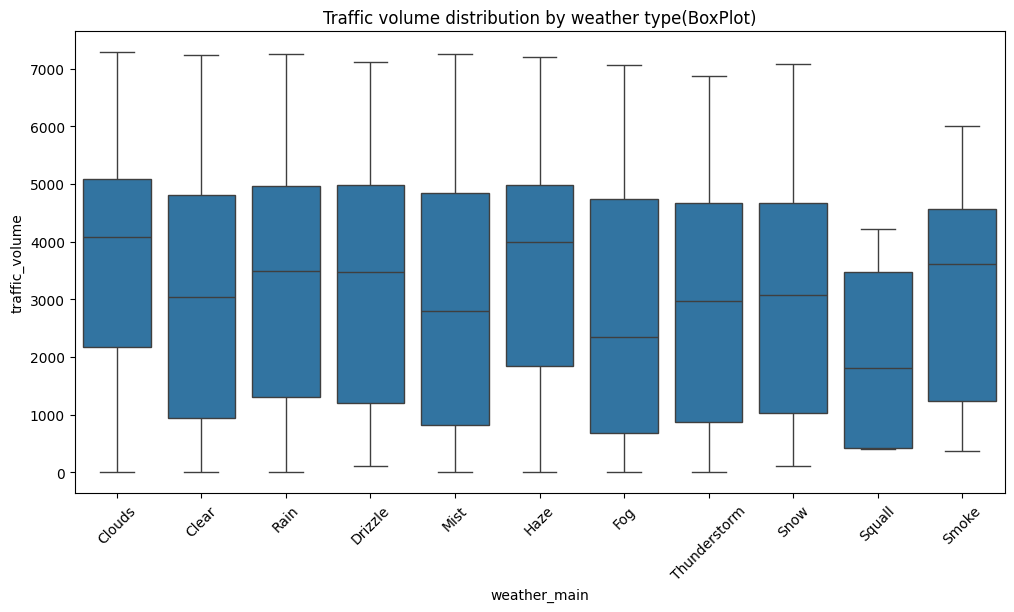

In [46]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = 'weather_main', y = 'traffic_volume', data=data)
plt.xticks(rotation=45)
plt.title('Traffic volume distribution by weather type(BoxPlot)')
plt.show()

    - Analysing the traffic of 24-hours of each day of the week

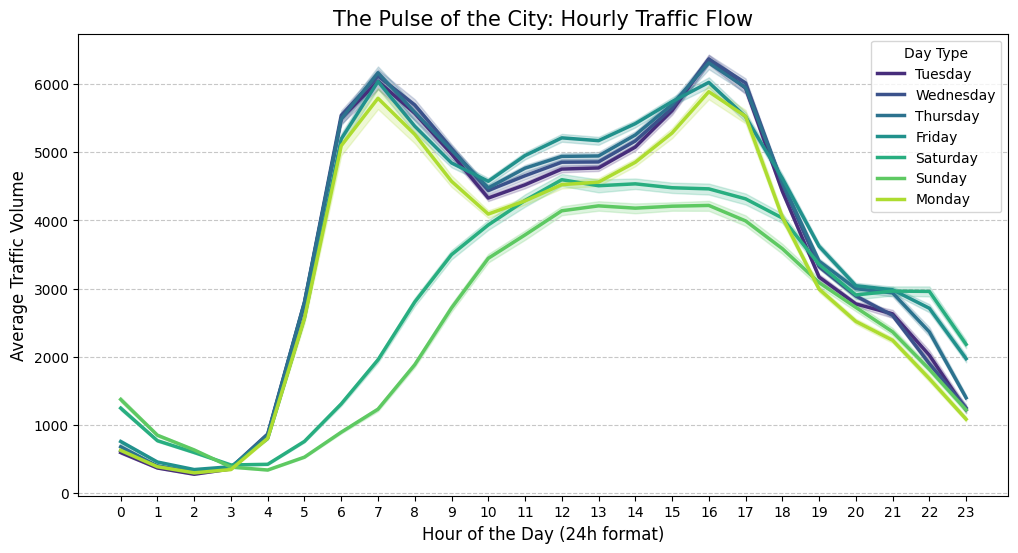

In [47]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='hour', y='traffic_volume', hue='day_name', palette='viridis', linewidth=2.5)

plt.title('The Pulse of the City: Hourly Traffic Flow', fontsize=15)
plt.xlabel('Hour of the Day (24h format)', fontsize=12)
plt.ylabel('Average Traffic Volume', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Day Type')
plt.show()

    - This graph shows 
- Between 1AM to 4AM morning traffic is lowest and gradually increasing after that.
- Sharp increasing in traffic after 4AM morning.
- Between 6AM to 7AM morning traffic is highest in morning during non-weekend days.
- A Sharp small dip in traffic after 8AM morning.
- Between 8AM morning to 3PM Afternoon Traffic is high but low compared to morning and evening peak on non weekend days.
- Between 4PM to 5PM in evening is highest traffic of the day during non-weekend days.
- After 5PM there is a sharp dip in traffic during non-weekend days.
- During weekend peak traffic is between 11AM morning to 5PM evening (steady).
- Traffic on weekends is usually low compared to non-weekend days.

    - Finding co-relation using HeatMap

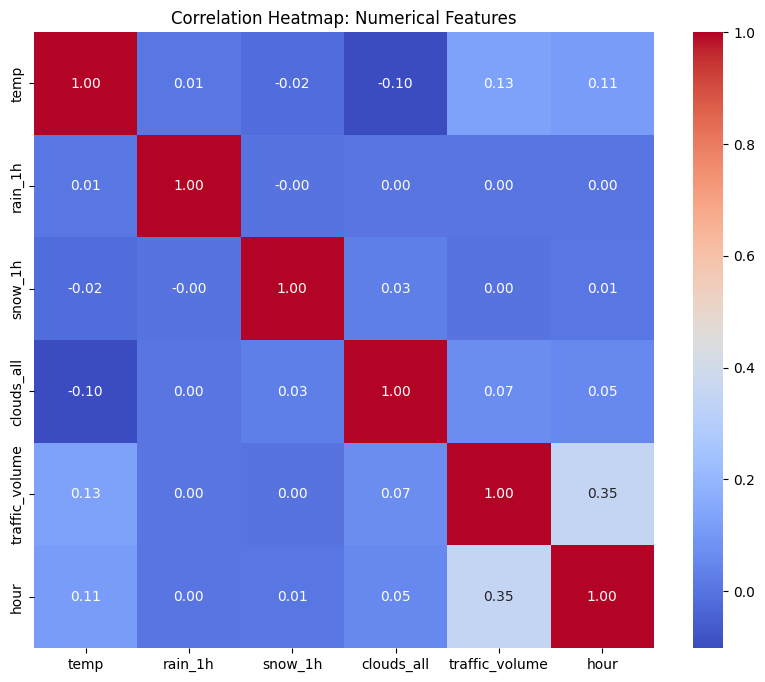

In [48]:
# Select only numerical columns for correlation
numerical_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume', 'hour']
correlation_matrix = data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Numerical Features')
plt.show()

    - This co-relation shows - All features are not too much corelated, hence all the features are important

In [49]:
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,is_holiday,temp_celsius,hour,day_name
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,1,15.13,9,Tuesday
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,1,16.21,10,Tuesday
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,1,16.43,11,Tuesday
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,1,16.98,12,Tuesday
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,1,17.99,13,Tuesday


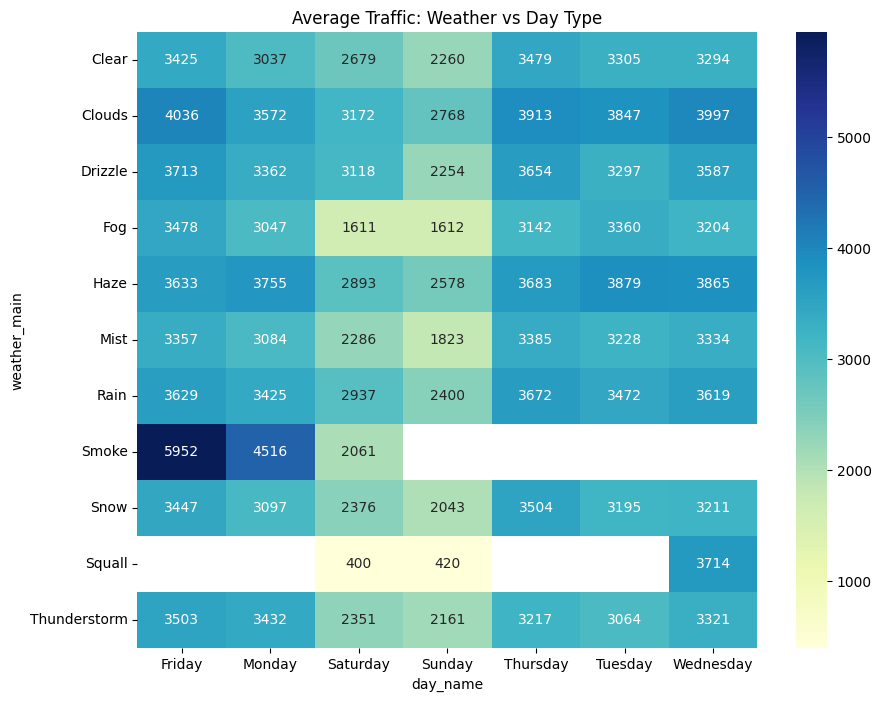

In [50]:
# Create a Pivot Table to see the interaction
pivot_table = data.pivot_table(values='traffic_volume', index='weather_main', columns='day_name', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Traffic: Weather vs Day Type')
plt.show()

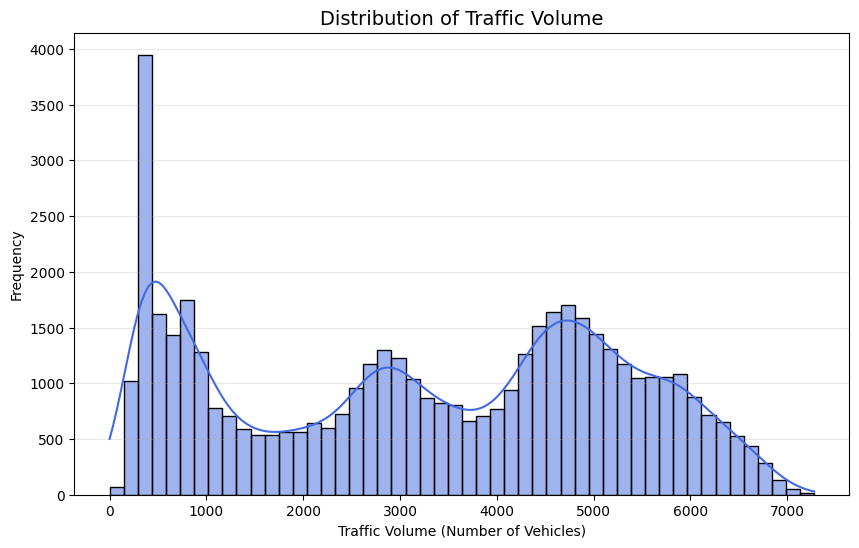

In [ ]:
plt.figure(figsize=(10, 6))
# Histogram + KDE (Kernel Density Estimate)
sns.histplot(data=data['traffic_volume'], kde=True, bins=50, color='royalblue')

plt.title('Distribution of Traffic Volume', fontsize=14)
plt.xlabel('Traffic Volume (Number of Vehicles)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Figure size 1000x500 with 0 Axes>

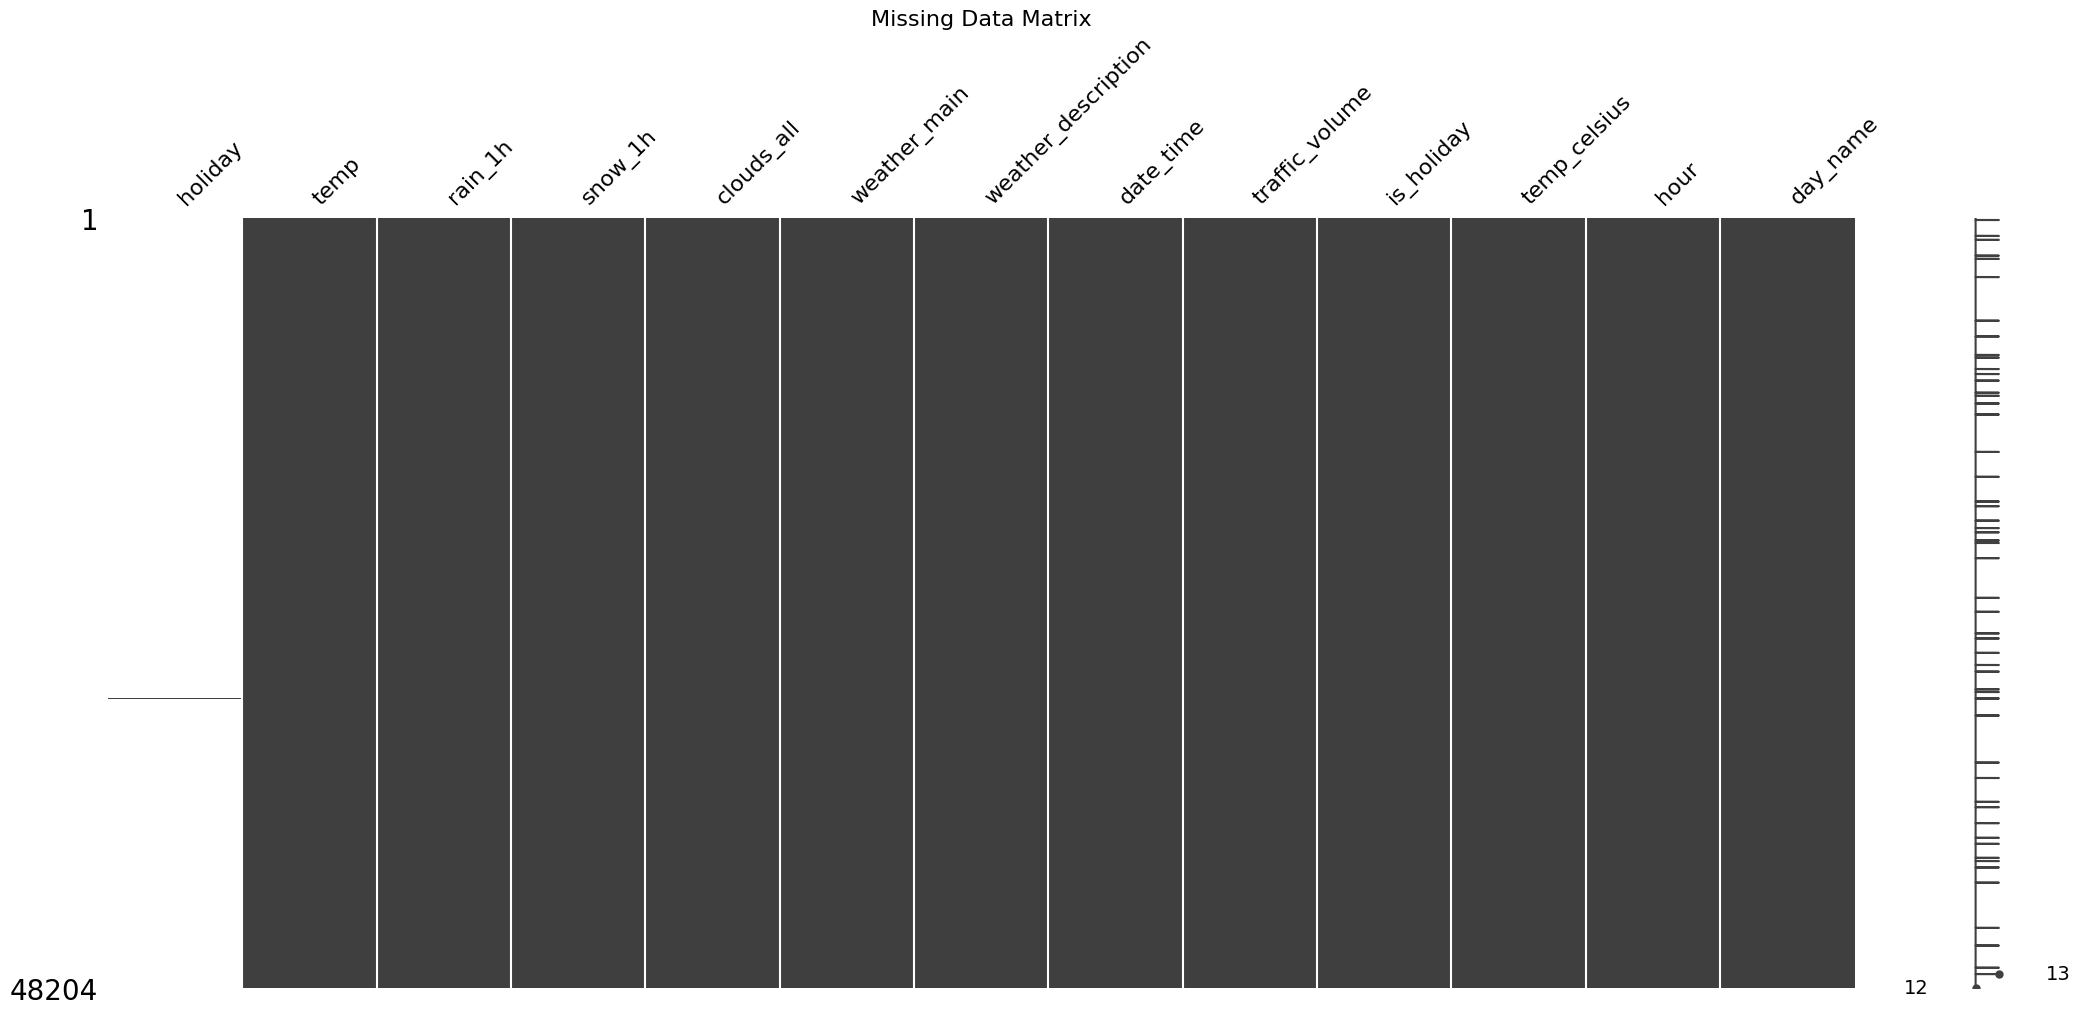


Missing values per column:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
is_holiday                 0
temp_celsius               0
hour                       0
day_name                   0
dtype: int64


In [53]:
import missingno as msno

# Visualizes the location of missing values
plt.figure(figsize=(10, 5))
msno.matrix(data)
plt.title('Missing Data Matrix', fontsize=16)
plt.show()

# Quick text summary of nulls
print("\nMissing values per column:")
print(data.isnull().sum())

In [55]:
# 1. Temperature Check (Looking for 0 Kelvin)
temp_errors = data[data['temp'] == 0]
print(f"Number of rows with 0 Kelvin (Error): {len(temp_errors)}")

# 2. Rain Check (Looking for the 9999mm glitch)
rain_errors = data[data['rain_1h'] > 500] # Standard heavy rain is usually < 50mm
print(f"Number of rows with impossible rainfall (>500mm): {len(rain_errors)}")

# 3. Descriptive Stats for all numerical features
# This helps you spot if 'min' or 'max' values look physically impossible
print("\nNumerical Statistics Summary:")
display(data[['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']].describe())

Number of rows with 0 Kelvin (Error): 10
Number of rows with impossible rainfall (>500mm): 1

Numerical Statistics Summary:


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000
